**Датасет:** https://www.kaggle.com/datasets/mragpavank/insurance1

**Задача аппроксимации:** Определение стоимости медицинской страховки на основе данных о клиенте.

Выходная переменная: `charges`.
Входные переменные, которые влияют на `charges`: `age` и `smoker`.

In [50]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 Загрузка датасета и обработка данных

In [51]:
google_drive_path = '/content/drive/MyDrive/ТУСУР 425-М/1 курс/2 семестр/Интеллектуальные вычислительные системы (ИВС)'
dataset_path = f'{google_drive_path}/insurance.csv'

data = pd.read_csv(dataset_path)
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [52]:
print(data.isnull().sum())

print(data.duplicated().sum())

if data.duplicated().sum() > 0:
  data = data.drop_duplicates()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
1


## 2 Преобразование нечисловых данных в числовые

In [53]:
data_formalized = data.copy()

data_formalized['sex'] = data_formalized['sex'].map({'male': 1, 'female': 0})

data_formalized['smoker'] = data_formalized['smoker'].map({'yes': 1, 'no': 0})

data_formalized = pd.get_dummies(data_formalized, columns=['region'], drop_first=True, dtype=int)

data_formalized.head(10)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
5,31,0,25.740,0,0,3756.62160,0,1,0
6,46,0,33.440,1,0,8240.58960,0,1,0
7,37,0,27.740,3,0,7281.50560,1,0,0
8,37,1,29.830,2,0,6406.41070,0,0,0
9,60,0,25.840,0,0,28923.13692,1,0,0


## 3 Корреляционный анализ по методу Спирмена

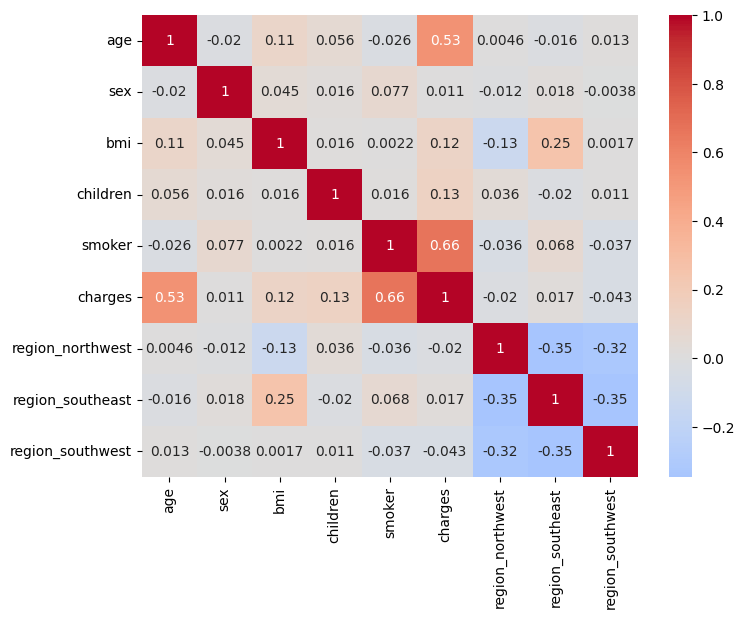

Корреляция признаков с выходной переменной charges: 
charges             1.000000
smoker              0.663611
age                 0.533523
children            0.132200
bmi                 0.119585
region_southeast    0.016609
sex                 0.010748
region_northwest   -0.019546
region_southwest   -0.043095
Name: charges, dtype: float64


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

spearman_corr = data_formalized.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, cmap='coolwarm', annot=True, center=0)
plt.show()

corr_with_target = spearman_corr["charges"].sort_values(ascending=False)
print(f'Корреляция признаков с выходной переменной charges: \n{corr_with_target}')

## 4 Выбор 2-х наиболее значимых переменных

smoker    0.663611
age       0.533523
Name: charges, dtype: float64


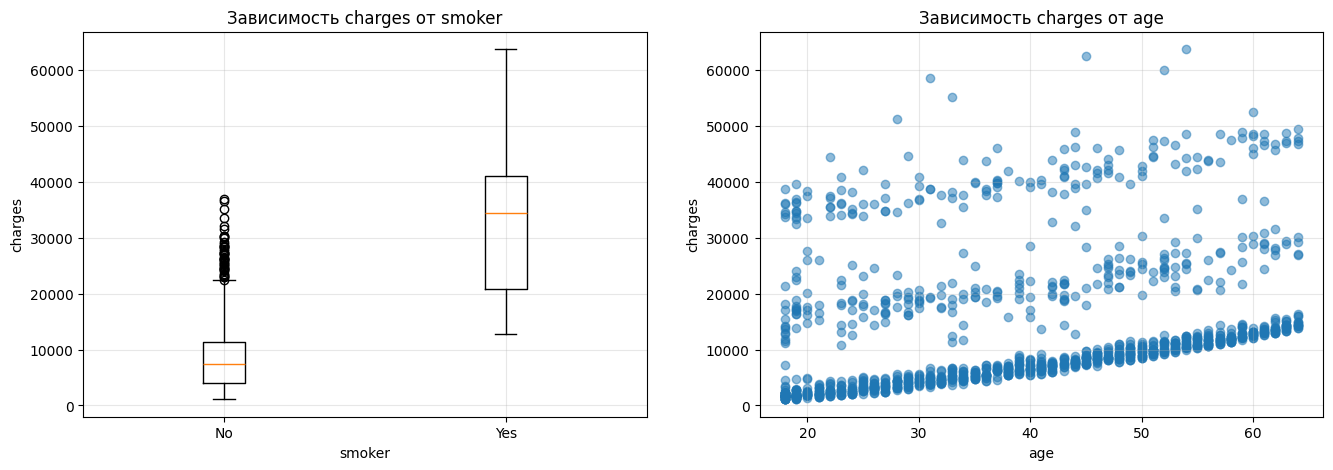

In [55]:
top_features = corr_with_target.drop('charges').head(2)
print(top_features)

selected_features = list(top_features.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot([data[data['smoker'] == 'no']['charges'],
                 data[data['smoker'] == 'yes']['charges']],
                tick_labels=['No', 'Yes'])
axes[0].set_xlabel('smoker')
axes[0].set_ylabel('charges')
axes[0].set_title('Зависимость charges от smoker')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(data['age'], data['charges'], alpha=0.5)
axes[1].set_xlabel('age')
axes[1].set_ylabel('charges')
axes[1].set_title('Зависимость charges от age')
axes[1].grid(True, alpha=0.3)

plt.show()

## 5 Очистка датасета от выбросов

In [56]:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010



age:
 -нижняя граница: -9.00
 -верхняя граница: 87.00
 -количество выбросов: 0 (0.00%)

charges:
 -нижняя граница: -13120.72
 -верхняя граница: 34524.78
 -количество выбросов: 139 (10.40%)


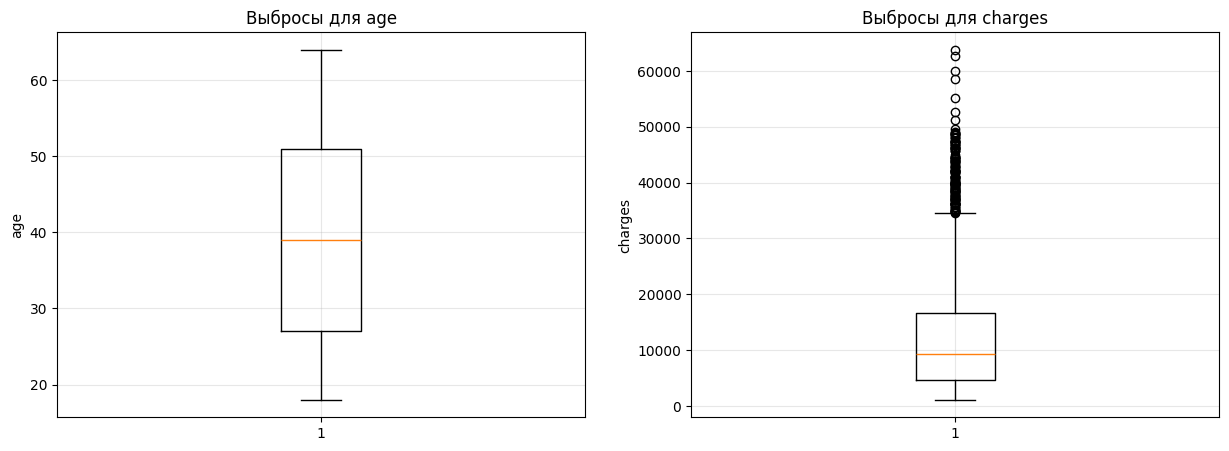

In [57]:
# Обнаружение выбросов методом межквартильного размаха
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Анализируем выбросы только для выбранных переменных
# Для smoker не надо анализировать, потому что там либо да, либо нет
numerical_features = ['age', 'charges']

for feature in numerical_features:
    outliers, lower, upper = detect_outliers_iqr(data, feature)
    print(f"\n{feature}:")
    print(f" -нижняя граница: {lower:.2f}")
    print(f" -верхняя граница: {upper:.2f}")
    print(f" -количество выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, feature in enumerate(numerical_features):
    axes[idx].boxplot(data[feature])
    axes[idx].set_title(f'Выбросы для {feature}')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(True, alpha=0.3)

plt.show()

Исходный размер датасета: 1337 строк
После удаления выбросов по age осталось: 1337 строк
После удаления выбросов по charges осталось: 1198 строк

Всего удалено выбросов: 139 (10.40%)


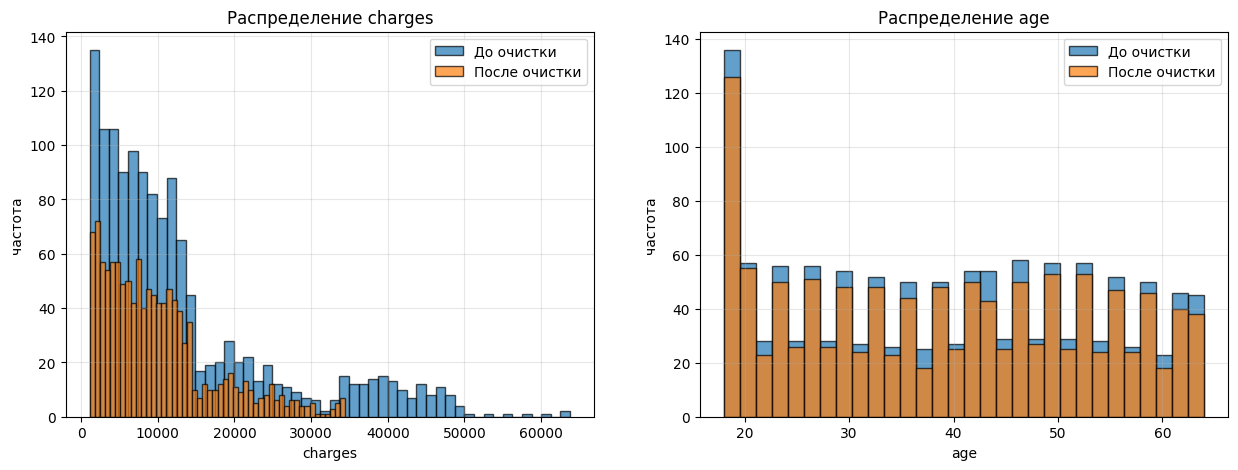

In [58]:
# Удаление выбросов из датасета
print(f"Исходный размер датасета: {len(data)} строк")

data_clean = data.copy()

outliers_age, lower_age, upper_age = detect_outliers_iqr(data_clean, 'age')
data_clean = data_clean[
    (data_clean['age'] >= lower_age) &
    (data_clean['age'] <= upper_age)
]
print(f"После удаления выбросов по age осталось: {len(data_clean)} строк")

outliers_charges, lower_charges, upper_charges = detect_outliers_iqr(data_clean, 'charges')
data_clean = data_clean[
    (data_clean['charges'] >= lower_charges) &
    (data_clean['charges'] <= upper_charges)
]
print(f"После удаления выбросов по charges осталось: {len(data_clean)} строк")

print(f"\nВсего удалено выбросов: {len(data) - len(data_clean)} ({(len(data) - len(data_clean))/len(data)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(data['charges'], bins=50, alpha=0.7, label='До очистки', edgecolor='black')
axes[0].hist(data_clean['charges'], bins=50, alpha=0.7, label='После очистки', edgecolor='black')
axes[0].set_xlabel('charges')
axes[0].set_ylabel('частота')
axes[0].set_title('Распределение charges')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(data['age'], bins=30, alpha=0.7, label='До очистки', edgecolor='black')
axes[1].hist(data_clean['age'], bins=30, alpha=0.7, label='После очистки', edgecolor='black')
axes[1].set_xlabel('age')
axes[1].set_ylabel('частота')
axes[1].set_title('Распределение age')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

## 6 Разбиение датасета на обучающую и экспериментальную выборки

In [59]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data_clean, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {len(train_data)} строк ({len(train_data)/len(data_clean)*100:.1f}%)")
print(f"Размер тестовой выборки: {len(test_data)} строк ({len(test_data)/len(data_clean)*100:.1f}%)")

clean_path = f'{google_drive_path}/insurance_clean.csv'
train_path = f'{google_drive_path}/insurance_train.csv'
test_path = f'{google_drive_path}/insurance_test.csv'

data_clean.to_csv(clean_path, index=False)
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

Размер обучающей выборки: 838 строк (69.9%)
Размер тестовой выборки: 360 строк (30.1%)


## 7 Разбиение на термы

In [60]:
TERM_NUMBER = 5

AGE_MIN = data_clean['age'].min()
AGE_MAX = data_clean['age'].max()

term_names = ['очень низкий', 'низкий', 'средний', 'высокий', 'очень высокий']

x = np.linspace(AGE_MIN, AGE_MAX, 200)

SMOKER_TERM_NAMES = ['некурящий', 'курящий']

SMOKER_MIN = 0
SMOKER_MAX = 1
x_smoker = np.linspace(SMOKER_MIN, SMOKER_MAX, 200)

### 7.1 Термы для треугольной функции принадлежности

In [61]:
def generate_triangular_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else max_value - min_value

    terms = []
    for i in range(n_terms):
        if i == 0:
            a = min_value
            b = centers[i]
            c = centers[i] + step
        elif i == n_terms - 1:
            a = centers[i] - step
            b = centers[i]
            c = max_value
        else:
            a = centers[i] - step
            b = centers[i]
            c = centers[i] + step

        terms.append((a, b, c))

    return terms

age_triangular = generate_triangular_terms(AGE_MIN, AGE_MAX, TERM_NUMBER)

print("Треугольные термы для smoker:")
for name, (a, b, c) in zip(term_names, age_triangular):
    print(f"  {name:13s}: a = {a:.2f}, b = {b:.2f}, c = {c:.2f}")

smoker_triangular = [
    (SMOKER_MIN - 0.5, SMOKER_MIN, SMOKER_MIN + 0.5),
    (SMOKER_MAX - 0.5, SMOKER_MAX, SMOKER_MAX + 0.5)
]

print("Треугольные термы для smoker:")
for name, (a, b, c) in zip(SMOKER_TERM_NAMES, smoker_triangular):
    print(f"  {name:13s}: a = {a:.2f}, b = {b:.2f}, c = {c:.2f}")

Треугольные термы для smoker:
  очень низкий : a = 18.00, b = 18.00, c = 29.50
  низкий       : a = 18.00, b = 29.50, c = 41.00
  средний      : a = 29.50, b = 41.00, c = 52.50
  высокий      : a = 41.00, b = 52.50, c = 64.00
  очень высокий: a = 52.50, b = 64.00, c = 64.00
Треугольные термы для smoker:
  некурящий    : a = -0.50, b = 0.00, c = 0.50
  курящий      : a = 0.50, b = 1.00, c = 1.50


### 7.2 Термы для трапецеидальной функции принадлежности

In [62]:
def generate_trapezoidal_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else max_value - min_value

    terms = []
    for i in range(n_terms):
        if i == 0:
            a = min_value
            b = min_value
            c = centers[i] + step/2
            d = centers[i] + step
        elif i == n_terms - 1:
            a = centers[i] - step
            b = centers[i] - step/2
            c = max_value
            d = max_value
        else:
            a = centers[i] - step
            b = centers[i] - step/2
            c = centers[i] + step/2
            d = centers[i] + step

        terms.append((a, b, c, d))

    return terms

age_trapezoidal = generate_trapezoidal_terms(AGE_MIN, AGE_MAX, TERM_NUMBER)

print("\nТрапециевидные термы для age:")
for name, (a, b, c, d) in zip(term_names, age_trapezoidal):
    print(f"  {name:13s}: a = {a:.2f}, b = {b:.2f}, c = {c:.2f}, d = {d:.2f}")

smoker_trapezoidal = [
    (SMOKER_MIN - 0.5, SMOKER_MIN - 0.25, SMOKER_MIN + 0.25, SMOKER_MIN + 0.5),
    (SMOKER_MAX - 0.5, SMOKER_MAX - 0.25, SMOKER_MAX + 0.25, SMOKER_MAX + 0.5)
]

print("\nТрапециевидные термы для smoker:")
for name, (a, b, c, d) in zip(SMOKER_TERM_NAMES, smoker_trapezoidal):
    print(f"  {name:13s}: a = {a:.2f}, b = {b:.2f}, c = {c:.2f}, d = {d:.2f}")


Трапециевидные термы для age:
  очень низкий : a = 18.00, b = 18.00, c = 23.75, d = 29.50
  низкий       : a = 18.00, b = 23.75, c = 35.25, d = 41.00
  средний      : a = 29.50, b = 35.25, c = 46.75, d = 52.50
  высокий      : a = 41.00, b = 46.75, c = 58.25, d = 64.00
  очень высокий: a = 52.50, b = 58.25, c = 64.00, d = 64.00

Трапециевидные термы для smoker:
  некурящий    : a = -0.50, b = -0.25, c = 0.25, d = 0.50
  курящий      : a = 0.50, b = 0.75, c = 1.25, d = 1.50


### 7.3 Термы для параболической функции принадлежности

In [63]:
def generate_parabolic_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else max_value - min_value
    width = step

    terms = [(c, width) for c in centers]
    return terms

age_parabolic = generate_parabolic_terms(AGE_MIN, AGE_MAX, TERM_NUMBER)

print("Параболические термы для age:")
for name, (center, width) in zip(term_names, age_parabolic):
    print(f"  {name:13s}: центр = {center:.2f}, ширина = {width:.2f}")

smoker_parabolic = [
    (SMOKER_MIN, 0.5),
    (SMOKER_MAX, 0.5)
]

print("\nПараболические термы для smoker:")
for name, (center, width) in zip(SMOKER_TERM_NAMES, smoker_parabolic):
    print(f"  {name:13s}: центр = {center:.2f}, ширина = {width:.2f}")

Параболические термы для age:
  очень низкий : центр = 18.00, ширина = 11.50
  низкий       : центр = 29.50, ширина = 11.50
  средний      : центр = 41.00, ширина = 11.50
  высокий      : центр = 52.50, ширина = 11.50
  очень высокий: центр = 64.00, ширина = 11.50

Параболические термы для smoker:
  некурящий    : центр = 0.00, ширина = 0.50
  курящий      : центр = 1.00, ширина = 0.50


### 7.4 Термы для Гауссовой функции принадлежности

In [64]:
def generate_gaussian_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else max_value - min_value
    sigma = step

    terms = [(c, sigma) for c in centers]
    return terms

age_gaussian = generate_gaussian_terms(AGE_MIN, AGE_MAX, TERM_NUMBER)

print("Гауссовы термы для age:")
for name, (center, sigma) in zip(term_names, age_gaussian):
    print(f"  {name:13s}: центр = {center:.2f}, sigma = {sigma:.2f}")

smoker_gaussian = [
    (SMOKER_MIN, 0.3),
    (SMOKER_MAX, 0.3)
]

print("\nГауссовы термы для smoker:")
for name, (center, sigma) in zip(SMOKER_TERM_NAMES, smoker_gaussian):
    print(f"  {name:13s}: центр = {center:.2f}, sigma = {sigma:.2f}")

Гауссовы термы для age:
  очень низкий : центр = 18.00, sigma = 11.50
  низкий       : центр = 29.50, sigma = 11.50
  средний      : центр = 41.00, sigma = 11.50
  высокий      : центр = 52.50, sigma = 11.50
  очень высокий: центр = 64.00, sigma = 11.50

Гауссовы термы для smoker:
  некурящий    : центр = 0.00, sigma = 0.30
  курящий      : центр = 1.00, sigma = 0.30


## 8 Реализация функций принадлежности

### 8.1 Треугольная функция принадлежности

In [65]:
def triangular(x, a, b, c):
    # Обработка граничных случаев для предотвращения деления на ноль
    if a == b and b == c:
        return np.where(x == a, 1.0, 0.0)
    elif a == b:
        return np.maximum(0, np.minimum(1, (c - x) / (c - a)))
    elif b == c:
        return np.maximum(0, np.minimum(1, (x - a) / (b - a)))
    else:
        return np.maximum(
            np.minimum((x - a) / (b - a), (c - x) / (c - b)),
            0
        )

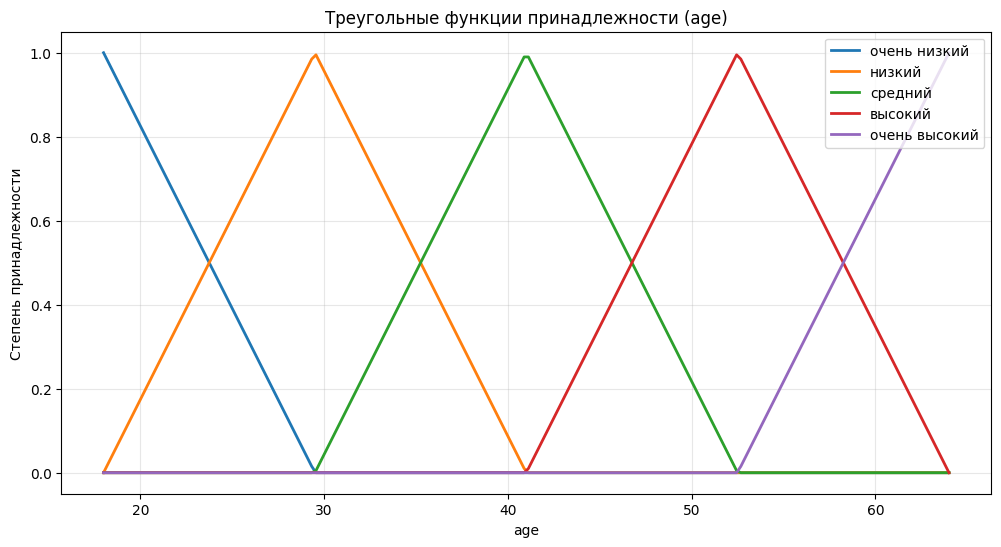

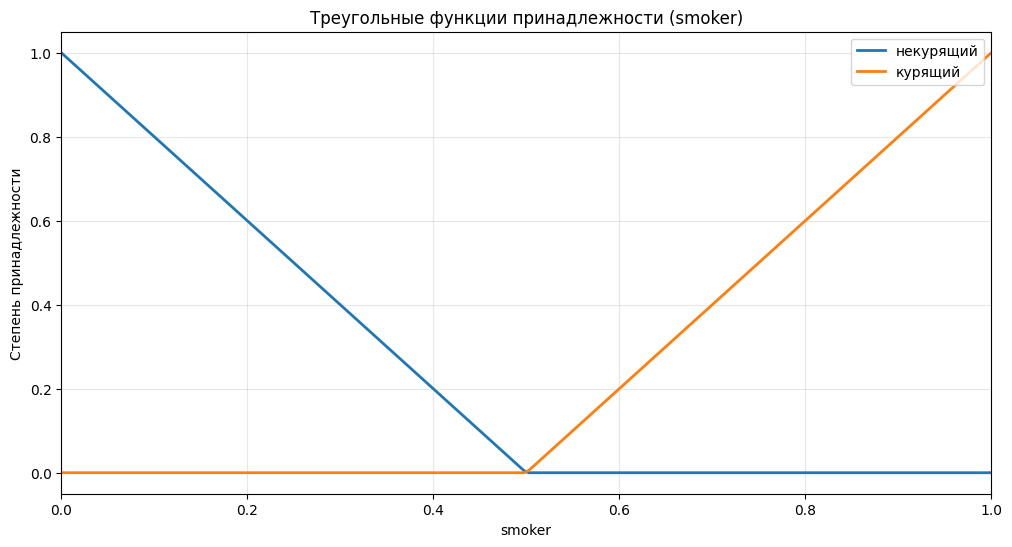

In [66]:
plt.figure(figsize=(12, 6))

for i, (a, b, c) in enumerate(age_triangular):
    mu = triangular(x, a, b, c)
    plt.plot(x, mu, linewidth=2, label=term_names[i])

plt.title('Треугольные функции принадлежности (age)')
plt.xlabel('age')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(12, 6))

for i, (a, b, c) in enumerate(smoker_triangular):
    mu = triangular(x_smoker, a, b, c)
    plt.plot(x_smoker, mu, linewidth=2, label=SMOKER_TERM_NAMES[i])

plt.title('Треугольные функции принадлежности (smoker)')
plt.xlabel('smoker')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

plt.show()

### 8.2 Трапециевидная функция принадлежности

In [67]:
def trapezoidal(x, a, b, c, d):
    # Обработка граничных случаев для предотвращения деления на ноль
    if a == b and c == d:
        return np.where((x >= a) & (x <= d), 1.0, 0.0)
    elif a == b:
        left_part = np.where(x >= a, 1.0, 0.0)
        right_part = np.where(x <= d, (d - x) / (d - c), 0.0)
        return np.minimum(left_part, np.maximum(right_part, 0))
    elif c == d:
        left_part = np.where(x >= a, (x - a) / (b - a), 0.0)
        right_part = np.where(x <= d, 1.0, 0.0)
        return np.minimum(np.maximum(left_part, 0), right_part)
    else:
        return np.maximum(
            np.minimum(
                np.minimum((x - a) / (b - a), 1),
                (d - x) / (d - c)
            ),
            0
        )

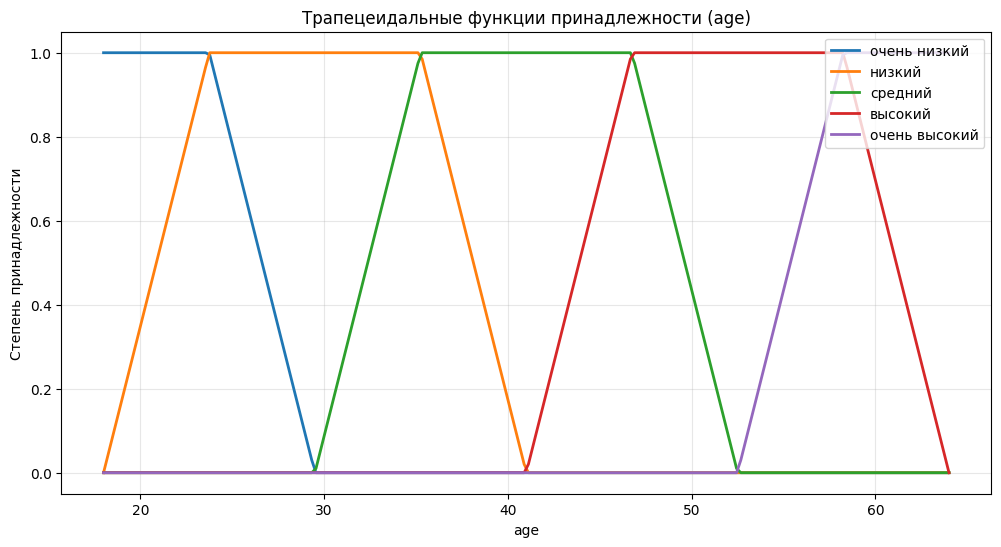

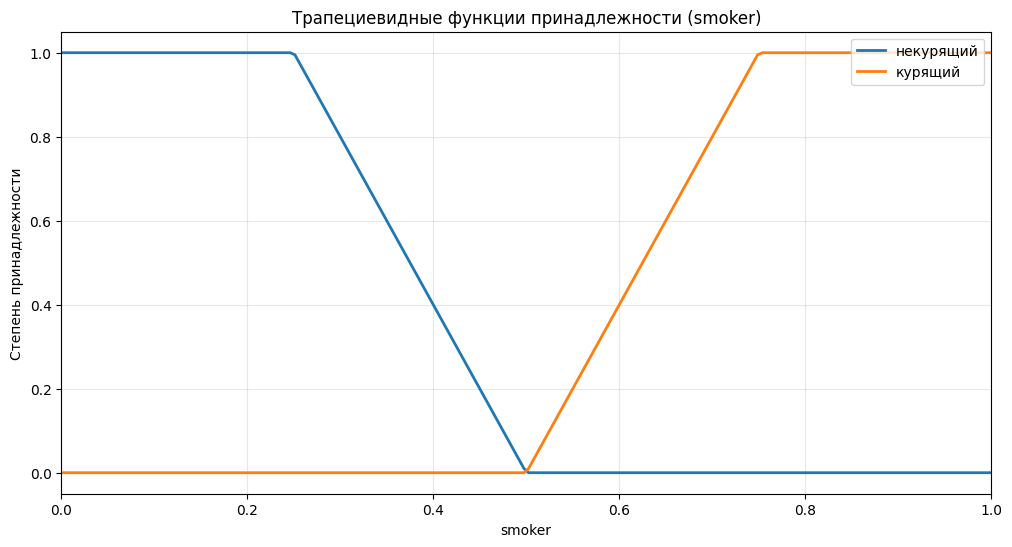

In [68]:
plt.figure(figsize=(12, 6))

for i, (a, b, c, d) in enumerate(age_trapezoidal):
    mu = trapezoidal(x, a, b, c, d)
    plt.plot(x, mu, linewidth=2, label=term_names[i])

plt.title('Трапецеидальные функции принадлежности (age)')
plt.xlabel('age')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(12, 6))

for i, (a, b, c, d) in enumerate(smoker_trapezoidal):
    mu = trapezoidal(x_smoker, a, b, c, d)
    plt.plot(x_smoker, mu, linewidth=2, label=SMOKER_TERM_NAMES[i])

plt.title('Трапециевидные функции принадлежности (smoker)')
plt.xlabel('smoker')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

plt.show()

### 8.3 Параболическая функция принадлежности

In [69]:
def parabolic(x, center, width):
    # Вырожденный случай
    if width == 0:
        return np.where(x == center, 1.0, 0.0)

    mu = 1 - ((x - center) / width) ** 2
    mu = np.where(np.abs(x - center) <= width, mu, 0)

    return np.maximum(mu, 0)

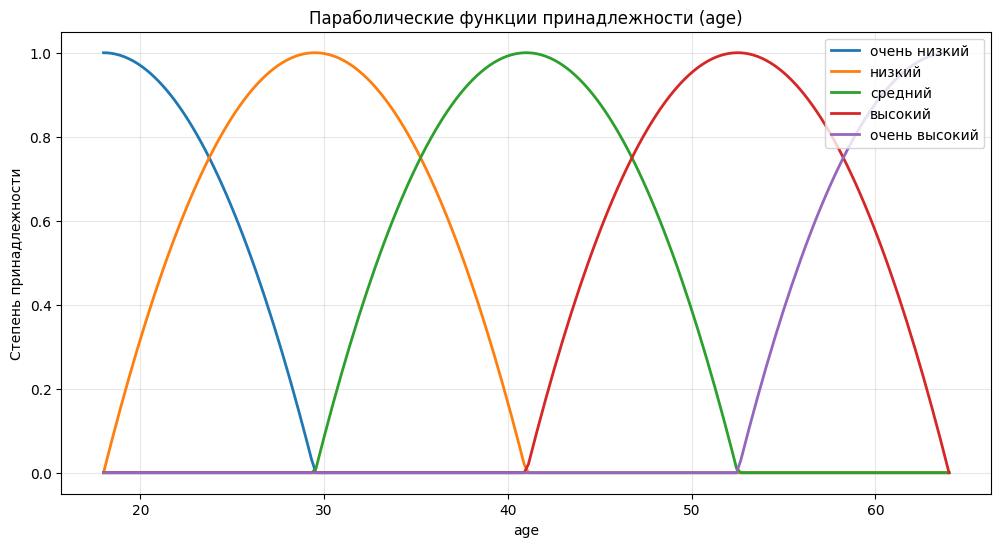

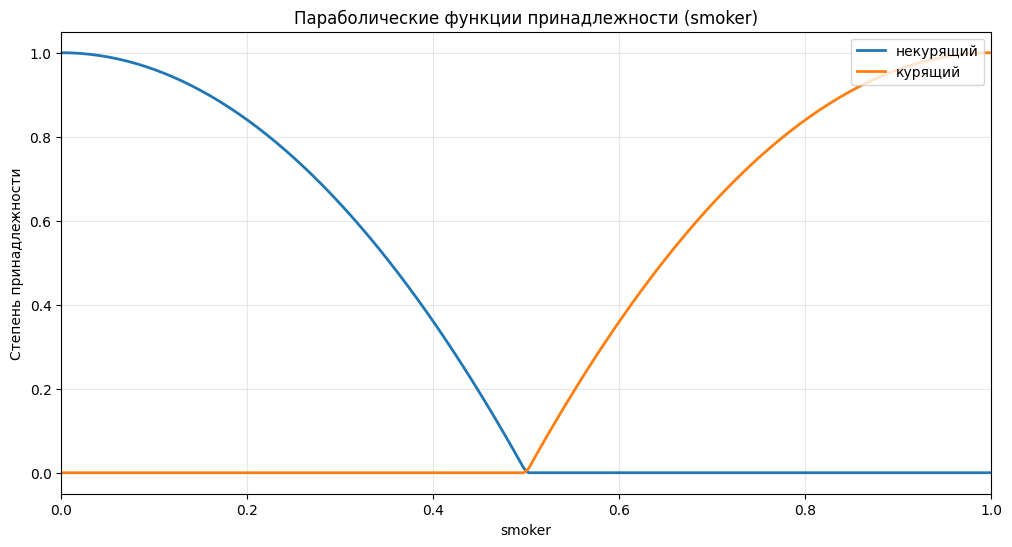

In [70]:
plt.figure(figsize=(12, 6))

for i, (center, width) in enumerate(age_parabolic):
    mu = parabolic(x, center, width)
    plt.plot(x, mu, linewidth=2, label=term_names[i])

plt.title('Параболические функции принадлежности (age)')
plt.xlabel('age')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(12, 6))

for i, (center, width) in enumerate(smoker_parabolic):
    mu = parabolic(x_smoker, center, width)
    plt.plot(x_smoker, mu, linewidth=2, label=SMOKER_TERM_NAMES[i])

plt.title('Параболические функции принадлежности (smoker)')
plt.xlabel('smoker')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

plt.show()

### 8.4 Гауссова функция принадлежности

In [71]:
def gaussian(x, mean, sigma):
    # Вырожденный случай
    if sigma == 0:
        return np.where(x == mean, 1.0, 0.0)

    return np.exp(-((x - mean) / sigma) ** 2)

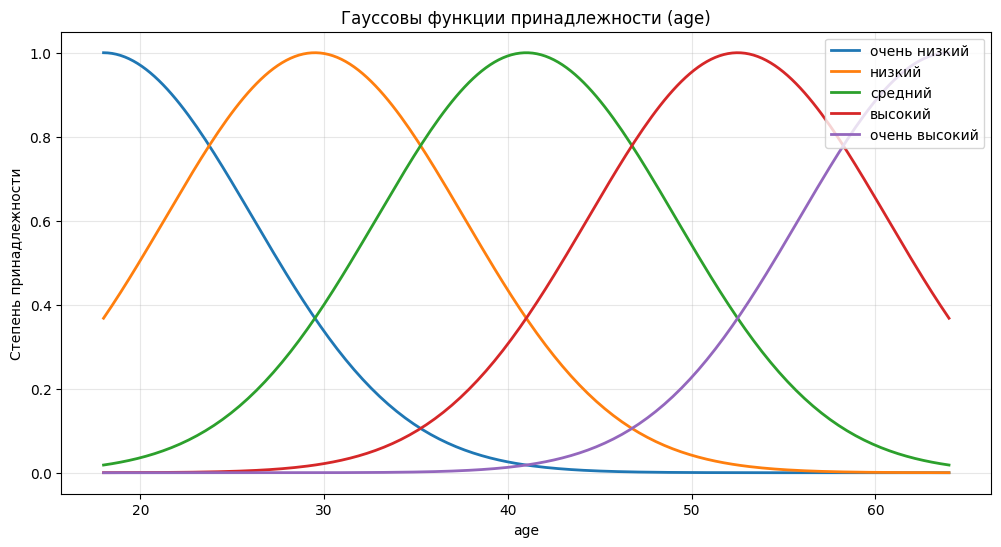

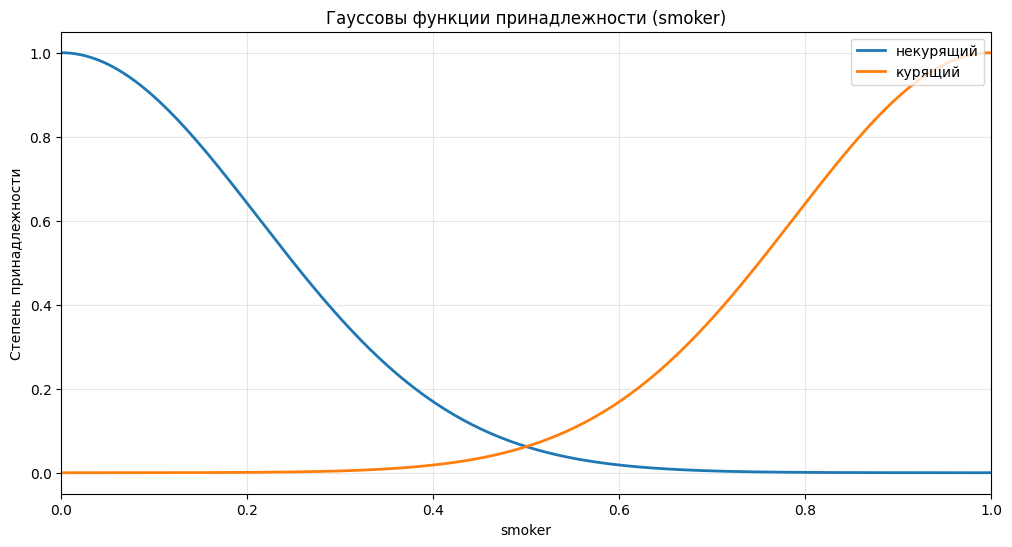

In [72]:
plt.figure(figsize=(12, 6))

for i, (mean, sigma) in enumerate(age_gaussian):
    mu = gaussian(x, mean, sigma)
    plt.plot(x, mu, linewidth=2, label=term_names[i])

plt.title('Гауссовы функции принадлежности (age)')
plt.xlabel('age')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(12, 6))

for i, (center, sigma) in enumerate(smoker_gaussian):
    mu = gaussian(x_smoker, center, sigma)
    plt.plot(x_smoker, mu, linewidth=2, label=SMOKER_TERM_NAMES[i])

plt.title('Гауссовы функции принадлежности (smoker)')
plt.xlabel('smoker')
plt.ylabel('Степень принадлежности')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

plt.show()